### Import python libararies for EDA

In [29]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns 
from matplotlib.ticker import MaxNLocator
import matplotlib.dates as mdates

In [30]:
pd.set_option('display.max_columns', None)  # Show all columns
pd.set_option('display.max_rows', None)     # Show all rows

### Import the consolidated data into a dataframe for EDA and Cleaning

In [31]:
filepath = '../data/raw/neiss_combined_raw_untouched_data.csv'
data_original = pd.read_csv(filepath, engine='pyarrow')

In [32]:
# Deep copy to preserve original data
data = data_original.copy()

In [33]:
data.shape

(7315732, 26)

The data has 7 Million observations and 26 features

In [34]:
data.describe()

,data_year,CPSC_Case_Number,Age,Sex,Race,Hispanic,Body_Part,Diagnosis,Body_Part_2,Diagnosis_2,Disposition,Location,Fire_Involvement,Product_1,Product_2,Product_3,Alcohol,Drug,PSU,Weight
count,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,2.031804e+06,7.315732e+06,7.315732e+06,449039.000000,449039.000000,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,7.315732e+06,2.031804e+06,2.031804e+06,7.315732e+06,7.315732e+06
mean,2.014283e+03,1.438899e+08,4.379820e+01,1.450022e+00,1.034293e+00,1.317193e+00,6.471971e+01,6.018758e+01,65.485708,61.034841,1.335680e+00,2.432491e+00,9.460844e-03,2.126031e+03,2.585908e+02,9.413754e+00,1.905007e-02,2.217143e-02,4.540746e+01,3.713500e+01
std,5.697235e+00,5.709018e+07,4.986483e+01,4.977646e-01,9.262696e-01,8.911552e-01,2.401576e+01,6.210480e+00,22.699428,7.163684,1.030898e+00,3.196199e+00,1.531823e-01,1.352375e+03,7.684433e+02,1.504334e+02,1.367010e-01,1.472409e-01,2.953424e+01,2.995122e+01
min,2.005000e+03,5.010034e+07,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.100000e+01,0.000000,41.000000,1.000000e+00,0.000000e+00,0.000000e+00,1.020000e+02,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,1.000000e+00,4.505600e+00
25%,2.009000e+03,9.121282e+07,1.200000e+01,1.000000e+00,0.000000e+00,0.000000e+00,3.600000e+01,5.700000e+01,35.000000,53.000000,1.000000e+00,0.000000e+00,0.000000e+00,1.211000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,2.100000e+01,1.485370e+01
50%,2.014000e+03,1.408530e+08,2.800000e+01,1.000000e+00,1.000000e+00,2.000000e+00,7.500000e+01,5.900000e+01,76.000000,59.000000,1.000000e+00,1.000000e+00,0.000000e+00,1.807000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,4.100000e+01,1.684130e+01
75%,2.019000e+03,1.908346e+08,5.800000e+01,2.000000e+00,1.000000e+00,2.000000e+00,8.200000e+01,6.400000e+01,82.000000,68.000000,1.000000e+00,4.000000e+00,0.000000e+00,3.272000e+03,0.000000e+00,0.000000e+00,0.000000e+00,0.000000e+00,6.700000e+01,6.903390e+01
max,2.024000e+03,2.503063e+08,2.230000e+02,2.000000e+00,6.000000e+00,2.000000e+00,9.400000e+01,7.400000e+01,94.000000,74.000000,9.000000e+00,9.000000e+00,3.000000e+00,5.555000e+03,5.555000e+03,5.555000e+03,1.000000e+00,1.000000e+00,2.070000e+02,1.121671e+02


In [35]:
data.info()

<class 'pandas.DataFrame'>
RangeIndex: 7315732 entries, 0 to 7315731
Data columns (total 26 columns):
 #   Column             Dtype  
---  ------             -----  
 0   data_year          int64  
 1   CPSC_Case_Number   int64  
 2   Treatment_Date     object 
 3   Age                int64  
 4   Sex                int64  
 5   Race               int64  
 6   Other_Race         str    
 7   Hispanic           float64
 8   Body_Part          int64  
 9   Diagnosis          int64  
 10  Other_Diagnosis    str    
 11  Body_Part_2        float64
 12  Diagnosis_2        float64
 13  Other_Diagnosis_2  str    
 14  Disposition        int64  
 15  Location           int64  
 16  Fire_Involvement   int64  
 17  Product_1          int64  
 18  Product_2          int64  
 19  Product_3          int64  
 20  Alcohol            float64
 21  Drug               float64
 22  Narrative_1        str    
 23  Stratum            str    
 24  PSU                int64  
 25  Weight             float64
dt

####  We need to understand the data in the raw file before performing feature engineering 


### Count of injury data by Year

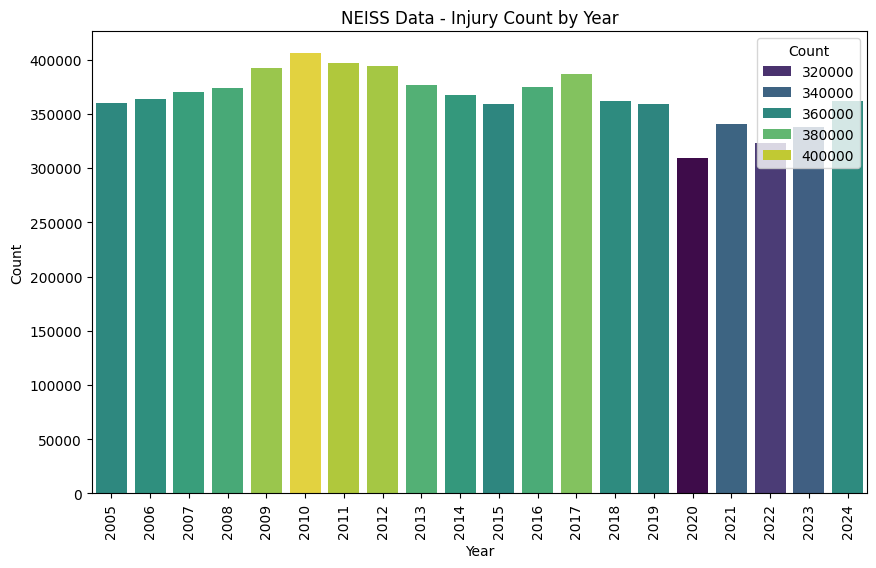

In [36]:
#data['data_year'] = pd.to_datetime(data['data_year'].astype(str), format='%Y')
injury_count_by_year = data.data_year.value_counts(ascending = False).reset_index()
injury_count_by_year.columns = ['Year', 'Count']
injury_count_by_year.sort_values(by='Year', ascending=True, inplace=True)
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Year', data=injury_count_by_year, hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data - Injury Count by Year')
plt.xticks(rotation=90)
plt.show()

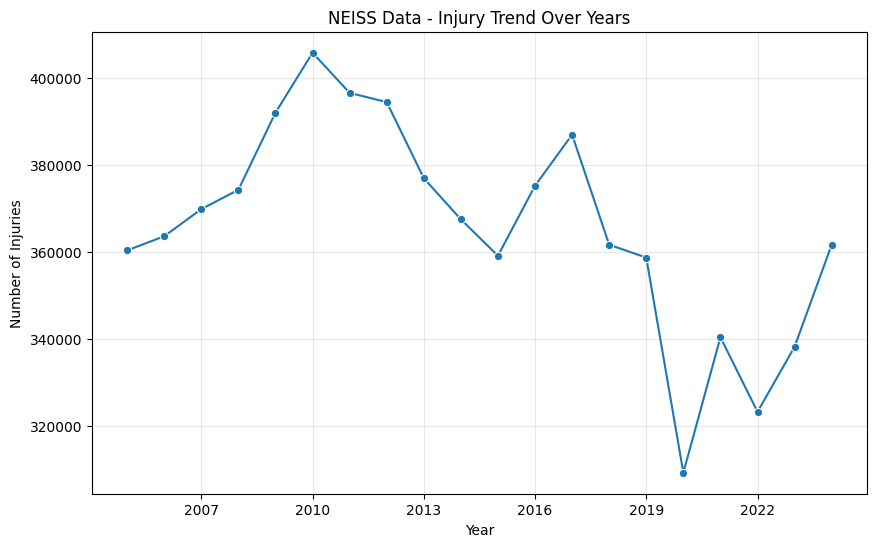

In [37]:
plt.figure(figsize=(10, 6))
sns.lineplot(data=injury_count_by_year, x='Year', y='Count', marker='o')
# Force the x-axis to only show integers (prevents "2015.5" labels)
plt.gca().xaxis.set_major_locator(MaxNLocator(integer=True))
plt.title('NEISS Data - Injury Trend Over Years')
plt.xlabel('Year')
plt.ylabel('Number of Injuries')
plt.grid(True, alpha=0.3) # Add a light grid for readability
plt.show()

#### Observations
1. The raw data in the file is kind of modelratly balanced when grouped at year level. <br>
2. There is dip in the injury information between 2019 and and 2022 - may be due to the COVID-19 pandemic and people staying at home - thereby reducing the number of overall injuries.

### Count of Injury data by Month 

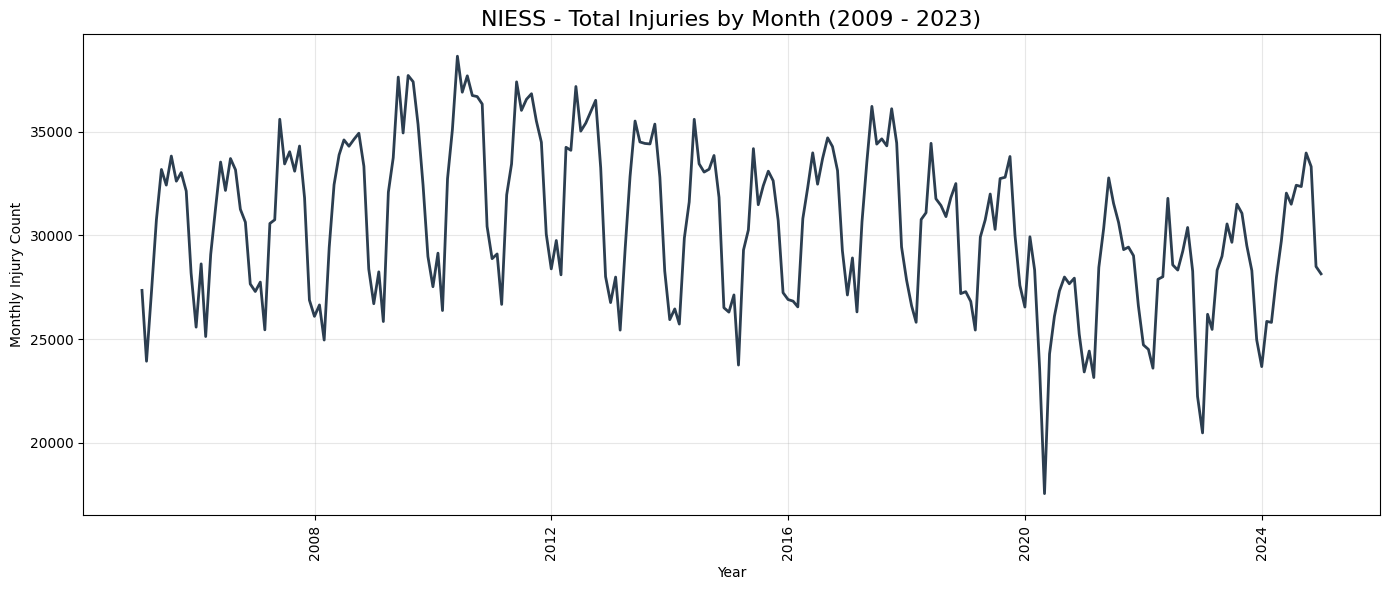

In [38]:
#Convert 'Treatment_Date' to datetime format
data['Treatment_Date'] = pd.to_datetime(data['Treatment_Date'].astype(str), format='%Y-%m-%d')
monthly_injury_counts = data.set_index('Treatment_Date').resample('ME').size().reset_index()
monthly_injury_counts.columns = ['Date', 'Count']
plt.figure(figsize=(14, 6))
sns.lineplot(data=monthly_injury_counts, x='Date', y='Count', linewidth=2, color='#2c3e50')
ax = plt.gca()
#ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
# Add grid and labels
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.title('NIESS - Total Injuries by Month (2009 - 2023)', fontsize=16)
plt.xlabel('Year')
plt.ylabel('Monthly Injury Count')
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

#### Observations
1. Seasonal Component - We see a seasonal component in the data for every year. The number of injuries peaks during the summer months and reduces in fall and spring. This could be possibly die to the reduction in mobility and social activities during these months. The only exception to this is seen in the year 2019-2020 where the the overall injury itself has reduced due to an external factor - the COVID 2019 factor. After the pandemic, the rate of injuries has slowely picked up and follows the seasonal trend like before. This shows the impact of external factors/shocks like the pandemic or mobility/economic (fewer people involved in recreational, work or public activities) reasons causing this decrement. The seaconal factor is robust and is predictable.<br>
2. The data exhibits a secoanl cyclicality and declining trend between 2005 to 2011 shows an upward trent in the injury counts where in 2011 it tapers off at 400K. The injury counts shows a slight decline between 2012 -2019 - this could be again due to an external factor like population or increase in the safety awareness contributing to the slight decline. 

The data points to three critical insights: (1) injury rates are heavily dependent on population mobility and economic activity, (2) seasonal factors remain robust and predictable, and (3) exogenous shocks (pandemic, policy changes) can produce sustained structural shifts in injury epidemiology. For public health planning and emergency preparedness, the pre-2020 baseline may no longer reflect current injury risk, and forward projections should account for the new post-pandemic normal.


### Univariate analysis of Injury data by age

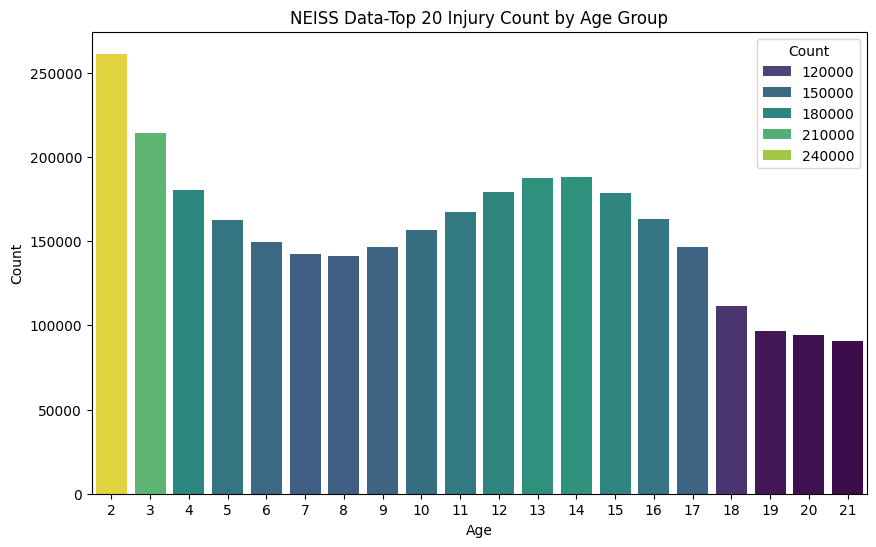

In [39]:
top20_injury_count_by_age = data.Age.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_age.columns = ['Age', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Age', data=top20_injury_count_by_age , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Top 20 Injury Count by Age Group')
plt.show()

#### Observations:
1. Maximum number of injuries seems to  observed for the age 2 <br>
2. After age 18, the number of injuries seems to stabilize 

### Injury data by Sex

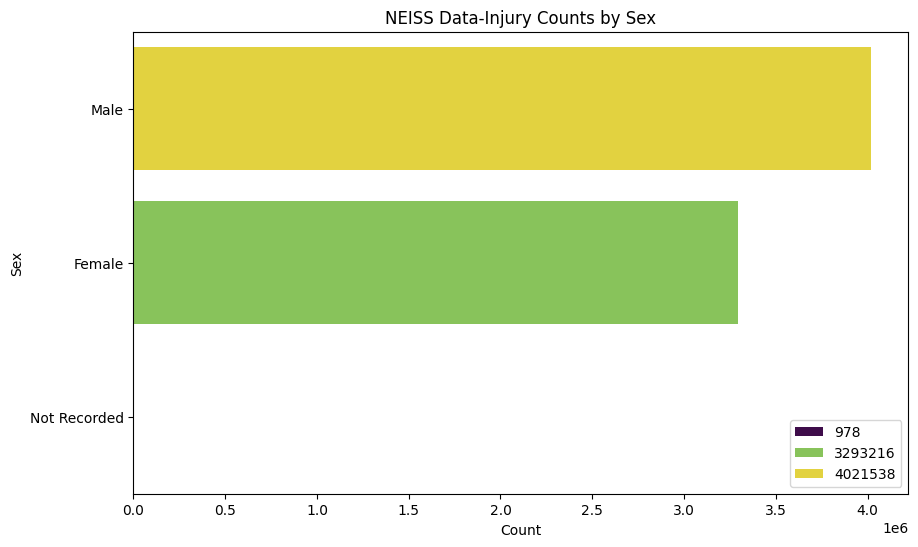

In [104]:
top20_injury_count_by_sex = data.Sex.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_sex.columns = ['Sex', 'Count']
sex = {0:'Not Recorded',1:'Male',2:'Female',3:'Non Binary/Other'}
plt.figure(figsize=(10,6))
top20_injury_count_by_sex.Sex = top20_injury_count_by_sex.Sex.map(sex)
sns.barplot(x='Count',y='Sex', data=top20_injury_count_by_sex , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Injury Counts by Sex')
plt.legend(loc='lower right')
plt.show()

### Injury data by Race

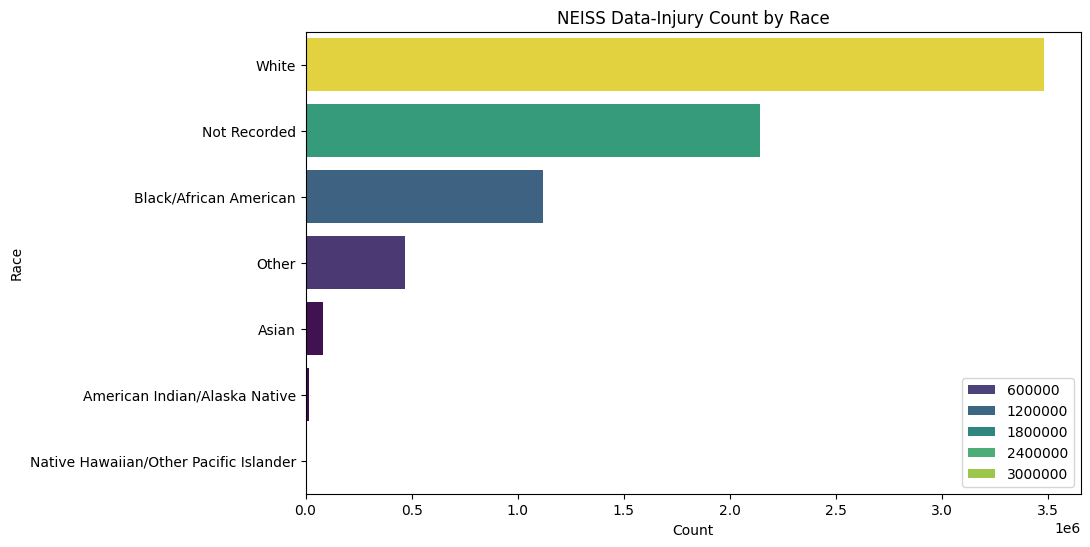

In [106]:
top20_injury_count_by_race = data.Race.value_counts().sort_values(ascending=False).reset_index().head(20)
top20_injury_count_by_race.columns = ['Race', 'Count']
race = {0:'Not Recorded',1:'White',2:'Black/African American',3:'Other',4:'Asian',5:'American Indian/Alaska Native',6:'Native Hawaiian/Other Pacific Islander'}
top20_injury_count_by_race.Race = top20_injury_count_by_race.Race.map(race)
plt.figure(figsize=(10,6))
sns.barplot(x='Count',y='Race', data=top20_injury_count_by_race , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Injury Count by Race')
plt.legend(loc='lower right')
plt.show()

#### Breakdown of Other Race

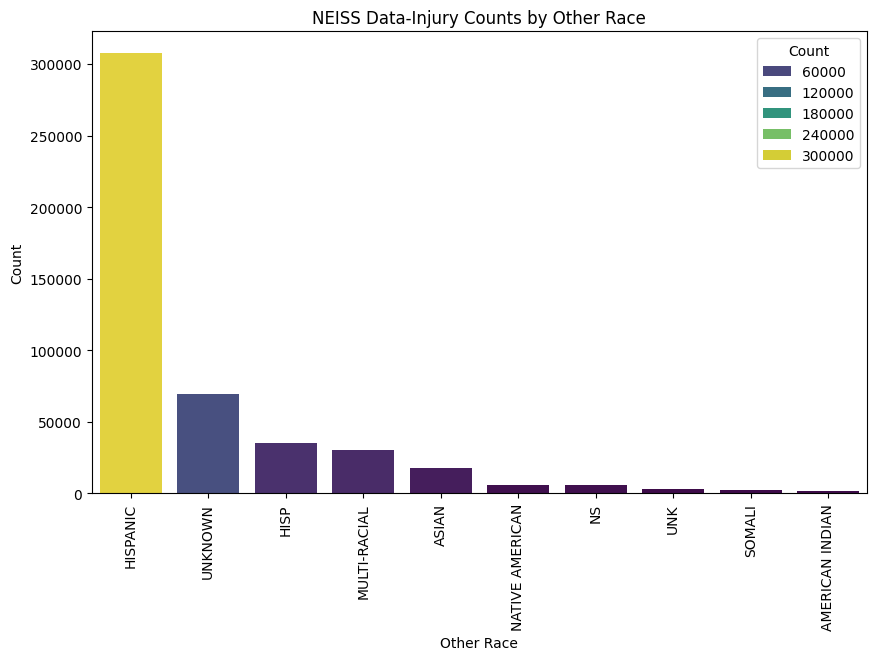

In [97]:
top10_injury_count_by_otherrace= data.Other_Race.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_otherrace.columns = ['Other Race', 'Count']
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Other Race', data=top10_injury_count_by_otherrace , hue='Count', dodge=False, palette='viridis')
plt.title('NEISS Data-Injury Counts by Other Race')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

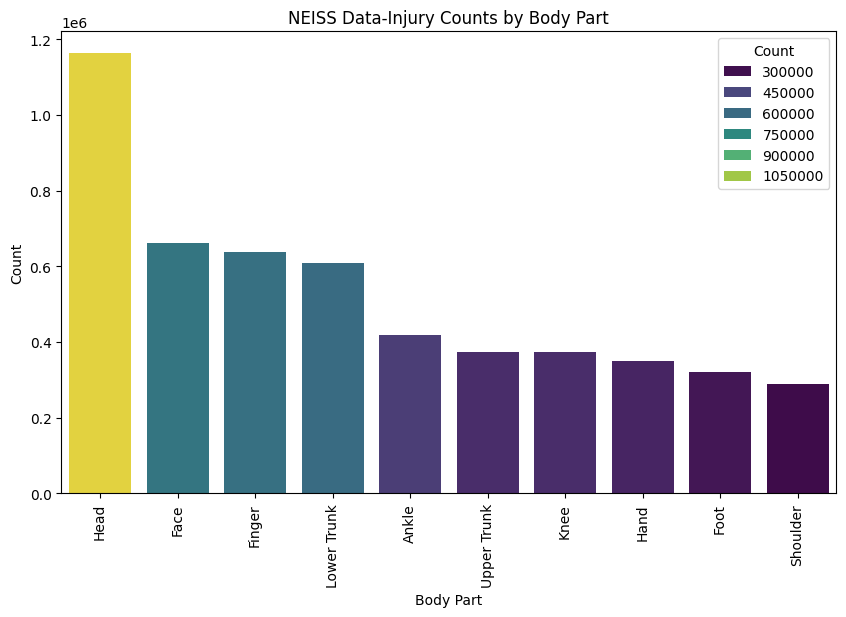

In [109]:
top10_injury_count_by_bodypart= data.Body_Part.value_counts().sort_values(ascending=False).reset_index().head(10)
top10_injury_count_by_bodypart.columns = ['Body Part', 'Count']
body_part_map = {
    0: 'Internal',
    30: 'Shoulder',
    31: 'Upper Trunk',
    32: 'Elbow',
    33: 'Lower Arm',
    34: 'Wrist',
    35: 'Knee',
    36: 'Lower Leg',
    37: 'Ankle',
    38: 'Pubic Region',
    75: 'Head',
    76: 'Face',
    77: 'Eyeball',
    79: 'Lower Trunk',
    80: 'Upper Arm',
    81: 'Upper Leg',
    82: 'Hand',
    83: 'Foot',
    84: '25-50pcnt of Body',
    85: 'All Parts Body',
    87: 'Not Stated/Unk',
    88: 'Mouth',
    89: 'Neck',
    92: 'Finger',
    93: 'Toe',
    94: 'Ear'
}

top10_injury_count_by_bodypart['Body Part'] = top10_injury_count_by_bodypart['Body Part'].map(body_part_map)
sort_order = top10_injury_count_by_bodypart['Body Part'].tolist()
plt.figure(figsize=(10,6))
sns.barplot(y='Count',x='Body Part', data=top10_injury_count_by_bodypart , hue='Count', dodge=False, palette='viridis', order=sort_order)
plt.title('NEISS Data-Injury Counts by Body Part')
plt.xticks(rotation=90) # Rotate years to prevent overlap
plt.show()

